In [1]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_final = pd.read_csv("/content/drive/MyDrive/Combine_dataset/btc_final_dataset.csv")

In [ ]:
df_final.shape

(8019, 25)

In [ ]:
df_final.head()

,date_30m,open,high,low,close,volume,tweet_count,vader_mean,bert_mean,ed_joy_mean,...,ed_others_mean,vader_influence,bert_influence,ed_joy_influence,ed_sadness_influence,ed_anger_influence,ed_surprise_influence,ed_disgust_influence,ed_fear_influence,ed_others_influence
0,2021-02-05 10:30:00+00:00,37532.15,37549.98,37354.09,37395.91,1004.783511,7,0.499743,0.496921,0.218451,...,0.701128,0.523925,0.476479,0.200395,0.002106,0.002193,0.004380,0.002182,0.110912,0.677832
1,2021-02-05 11:00:00+00:00,37395.92,37713.48,37395.78,37710.00,1151.152518,38,0.136595,0.185188,0.051286,...,0.931126,0.126673,0.177932,0.049518,0.001483,0.001801,0.003901,0.006981,0.003479,0.932837
2,2021-02-05 11:30:00+00:00,37709.99,37733.75,37561.00,37691.32,1013.996945,32,0.073659,0.206985,0.067796,...,0.832645,0.107015,0.233185,0.063925,0.001755,0.002249,0.036392,0.015516,0.030965,0.849197
3,2021-02-05 12:00:00+00:00,37691.32,38000.00,37527.14,37934.92,1934.036880,56,0.105086,0.173712,0.045141,...,0.884536,0.113878,0.165533,0.052328,0.001531,0.002608,0.020162,0.038244,0.002826,0.882302
4,2021-02-05 12:30:00+00:00,37934.91,38151.69,37800.00,37850.36,2263.920456,60,0.313377,0.412711,0.166651,...,0.771604,0.296935,0.408650,0.167453,0.001417,0.020831,0.004614,0.035015,0.005969,0.764700


═══════════════════════════════════════════════════════
  THỐNG KÊ RETURN 30 PHÚT (%)
═══════════════════════════════════════════════════════
  Mean   : -0.0040%
  Std    : 1.0749%
  Min    : -26.4034%
  Max    : 36.7244%
  25%    : -0.2540%
  75%    : 0.2467%
═══════════════════════════════════════════════════════

  PHÂN BỔ NHÃN THEO CÁC NGƯỠNG KHÁC NHAU:
    Ngưỡng |     Giảm |   Đi ngang |     Tăng |  Cân bằng?
  -------------------------------------------------------
      0.1% |    38.8% |      22.0% |    39.2% | ✅ Tốt
      0.2% |    29.3% |      41.9% |    28.8% | ✅ Tốt
      0.3% |    21.9% |      56.9% |    21.2% | ❌ Lệch nhiều
      0.5% |    12.1% |      75.6% |    12.2% | ❌ Lệch nhiều
      0.8% |     7.1% |      86.1% |     6.8% | ❌ Lệch nhiều
      1.0% |     4.3% |      91.6% |     4.1% | ❌ Lệch nhiều


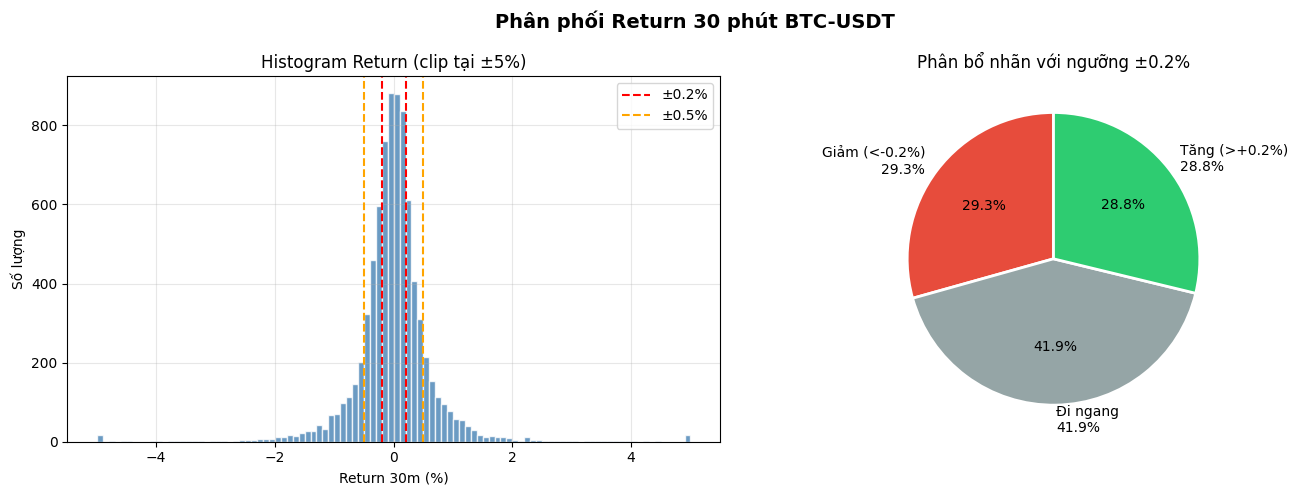

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ─── 1. TÍNH RETURN 30 PHÚT ──────────────────────────────────────────
df_final = df_final.sort_values('date_30m').reset_index(drop=True)
df_final['return_30m'] = df_final['close'].pct_change() * 100  # Đơn vị: %

returns = df_final['return_30m'].dropna()

print("═"*55)
print("  THỐNG KÊ RETURN 30 PHÚT (%)")
print("═"*55)
print(f"  Mean   : {returns.mean():.4f}%")
print(f"  Std    : {returns.std():.4f}%")
print(f"  Min    : {returns.min():.4f}%")
print(f"  Max    : {returns.max():.4f}%")
print(f"  25%    : {returns.quantile(0.25):.4f}%")
print(f"  75%    : {returns.quantile(0.75):.4f}%")
print("═"*55)

# ─── 2. THỬ NHIỀU NGƯỠNG → XEM PHÂN BỔ NHÃN ─────────────────────────
thresholds = [0.1, 0.2, 0.3, 0.5, 0.75, 1.0]

print("\n  PHÂN BỔ NHÃN THEO CÁC NGƯỠNG KHÁC NHAU:")
print(f"  {'Ngưỡng':>8} | {'Giảm':>8} | {'Đi ngang':>10} | {'Tăng':>8} | {'Cân bằng?':>10}")
print("  " + "-"*55)

for t in thresholds:
    tang     = (returns >  t).sum()
    giam     = (returns < -t).sum()
    di_ngang = ((returns >= -t) & (returns <= t)).sum()
    total    = len(returns)

    p_tang     = tang     / total * 100
    p_giam     = giam     / total * 100
    p_di_ngang = di_ngang / total * 100

    # Đánh giá mức độ cân bằng (lý tưởng ~33% mỗi nhãn)
    imbalance = max(p_tang, p_giam, p_di_ngang) - min(p_tang, p_giam, p_di_ngang)
    balanced  = "✅ Tốt" if imbalance < 20 else ("⚠️ Chấp nhận" if imbalance < 35 else "❌ Lệch nhiều")

    print(f"  {t:>7.1f}% | {p_giam:>7.1f}% | {p_di_ngang:>9.1f}% | {p_tang:>7.1f}% | {balanced}")

# ─── 3. BIỂU ĐỒ PHÂN PHỐI RETURN ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân phối Return 30 phút BTC-USDT', fontsize=14, fontweight='bold')

# Histogram
ax1 = axes[0]
ax1.hist(returns.clip(-5, 5), bins=100, color='steelblue', alpha=0.8, edgecolor='white')
for t_color, t_val in [('red', 0.2), ('orange', 0.5)]:
    ax1.axvline( t_val, color=t_color, linestyle='--', linewidth=1.5, label=f'±{t_val}%')
    ax1.axvline(-t_val, color=t_color, linestyle='--', linewidth=1.5)
ax1.set_xlabel('Return 30m (%)')
ax1.set_ylabel('Số lượng')
ax1.set_title('Histogram Return (clip tại ±5%)')
ax1.legend()
ax1.grid(alpha=0.3)

# Pie chart với ngưỡng ±0.2%
ax2 = axes[1]
t_chosen = 0.2
sizes = [
    (returns < -t_chosen).sum(),
    ((returns >= -t_chosen) & (returns <= t_chosen)).sum(),
    (returns >  t_chosen).sum()
]
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
labels = [f'Giảm (<-{t_chosen}%)\n{sizes[0]/len(returns)*100:.1f}%',
          f'Đi ngang\n{sizes[1]/len(returns)*100:.1f}%',
          f'Tăng (>+{t_chosen}%)\n{sizes[2]/len(returns)*100:.1f}%']
ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title(f'Phân bổ nhãn với ngưỡng ±{t_chosen}%')

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# TẠO NHÃN XU HƯỚNG (TREND LABEL) VỚI NGƯỠNG ±0.2%
# Bài toán phân loại 3 nhãn: Tăng / Đi ngang / Giảm
# ══════════════════════════════════════════════════════════════════════
THRESHOLD = 0.002  # ±0.2%

# ─── 1. TÍNH RETURN VÀ GÁN NHÃN ──────────────────────────────────────
# return_30m: % thay đổi giá close so với phiên TRƯỚC
# trend     : nhãn xu hướng của phiên HIỆN TẠI (dùng để dự báo phiên t+1)
df_final = df_final.sort_values('date_30m').reset_index(drop=True)
df_final['return_30m'] = df_final['close'].pct_change()

# Nhãn cho phiên t+1: shift(-1) → nhãn của phiên KẾ TIẾP
# Mô hình nhìn vào phiên t để dự đoán trend của phiên t+1
df_final['trend'] = df_final['return_30m'].shift(-1).map(
    lambda r: 'Tăng' if r > THRESHOLD else ('Giảm' if r < -THRESHOLD else 'Đi ngang')
    if pd.notna(r) else None
)

# Mã hóa nhãn thành số (để dùng với mô hình ML)
# 0 = Giảm | 1 = Đi ngang | 2 = Tăng
LABEL_MAP = {'Giảm': 0, 'Đi ngang': 1, 'Tăng': 2}
df_final['trend_label'] = df_final['trend'].map(LABEL_MAP)

# Bỏ dòng cuối (không có nhãn vì không có phiên t+1)
df_final = df_final.dropna(subset=['trend', 'return_30m']).reset_index(drop=True)

# ─── 2. BÁO CÁO ──────────────────────────────────────────────────────
print("═"*55)
print("  DATASET CUỐI CÙNG — SẴN SÀNG HUẤN LUYỆN")
print("═"*55)
print(f"  Tổng số phiên 30m : {len(df_final):,}")
print(f"  Ngưỡng phân loại  : ±{THRESHOLD*100:.1f}%")
print(f"\n  Phân bổ nhãn dự báo (phiên t+1):")
counts = df_final['trend'].value_counts()
for label in ['Tăng', 'Đi ngang', 'Giảm']:
    n = counts.get(label, 0)
    print(f"    {label:>8} ({LABEL_MAP[label]}) : {n:>5,}  ({n/len(df_final)*100:.1f}%)")
print("═"*55)

═══════════════════════════════════════════════════════
  DATASET CUỐI CÙNG — SẴN SÀNG HUẤN LUYỆN
═══════════════════════════════════════════════════════
  Tổng số phiên 30m : 8,017
  Ngưỡng phân loại  : ±0.2%

  Phân bổ nhãn dự báo (phiên t+1):
        Tăng (2) : 2,307  (28.8%)
    Đi ngang (1) : 3,357  (41.9%)
        Giảm (0) : 2,353  (29.4%)
═══════════════════════════════════════════════════════


In [ ]:
# ─── 3. LƯU DATASET HOÀN CHỈNH ───────────────────────────────────────
SAVE_PATH = "/content/drive/MyDrive/Combine_dataset/btc_final_dataset_labeled.csv"
df_final.to_csv(SAVE_PATH, index=False)
print(f"\n✅ Đã lưu dataset hoàn chỉnh tại:\n   {SAVE_PATH}")
print(f"\n   Cột cuối cùng: {list(df_final.columns)}")
df_final[['date_30m', 'close', 'return_30m', 'trend', 'trend_label']].tail(10)


✅ Đã lưu dataset hoàn chỉnh tại:
   /content/drive/MyDrive/Combine_dataset/btc_final_dataset_labeled.csv

   Cột cuối cùng: ['date_30m', 'open', 'high', 'low', 'close', 'volume', 'tweet_count', 'vader_mean', 'bert_mean', 'ed_joy_mean', 'ed_sadness_mean', 'ed_anger_mean', 'ed_surprise_mean', 'ed_disgust_mean', 'ed_fear_mean', 'ed_others_mean', 'vader_influence', 'bert_influence', 'ed_joy_influence', 'ed_sadness_influence', 'ed_anger_influence', 'ed_surprise_influence', 'ed_disgust_influence', 'ed_fear_influence', 'ed_others_influence', 'return_30m', 'trend', 'trend_label']


,date_30m,close,return_30m,trend,trend_label
8007,2023-01-09 18:30:00+00:00,17350.71,-0.001489,Đi ngang,1.0
8008,2023-01-09 19:00:00+00:00,17327.34,-0.001347,Đi ngang,1.0
8009,2023-01-09 19:30:00+00:00,17293.69,-0.001942,Giảm,0.0
8010,2023-01-09 20:00:00+00:00,17248.32,-0.002624,Đi ngang,1.0
8011,2023-01-09 20:30:00+00:00,17221.29,-0.001567,Đi ngang,1.0
8012,2023-01-09 21:00:00+00:00,17233.16,0.000689,Giảm,0.0
8013,2023-01-09 21:30:00+00:00,17182.48,-0.002941,Đi ngang,1.0
8014,2023-01-09 22:00:00+00:00,17209.11,0.001550,Đi ngang,1.0
8015,2023-01-09 22:30:00+00:00,17204.83,-0.000249,Đi ngang,1.0
8016,2023-01-09 23:00:00+00:00,17171.08,-0.001962,Đi ngang,1.0


In [ ]:
df_final.head()

,date_30m,open,high,low,close,volume,tweet_count,vader_mean,bert_mean,ed_joy_mean,...,ed_joy_influence,ed_sadness_influence,ed_anger_influence,ed_surprise_influence,ed_disgust_influence,ed_fear_influence,ed_others_influence,return_30m,trend,trend_label
0,2021-02-05 11:00:00+00:00,37395.92,37713.48,37395.78,37710.00,1151.152518,38,0.136595,0.185188,0.051286,...,0.049518,0.001483,0.001801,0.003901,0.006981,0.003479,0.932837,0.008399,Đi ngang,1.0
1,2021-02-05 11:30:00+00:00,37709.99,37733.75,37561.00,37691.32,1013.996945,32,0.073659,0.206985,0.067796,...,0.063925,0.001755,0.002249,0.036392,0.015516,0.030965,0.849197,-0.000495,Tăng,2.0
2,2021-02-05 12:00:00+00:00,37691.32,38000.00,37527.14,37934.92,1934.036880,56,0.105086,0.173712,0.045141,...,0.052328,0.001531,0.002608,0.020162,0.038244,0.002826,0.882302,0.006463,Giảm,0.0
3,2021-02-05 12:30:00+00:00,37934.91,38151.69,37800.00,37850.36,2263.920456,60,0.313377,0.412711,0.166651,...,0.167453,0.001417,0.020831,0.004614,0.035015,0.005969,0.764700,-0.002229,Đi ngang,1.0
4,2021-02-05 13:00:00+00:00,37850.36,37982.93,37827.83,37912.43,1429.417631,60,0.146805,0.273375,0.104993,...,0.082037,0.001638,0.002234,0.004880,0.029130,0.009138,0.870943,0.001640,Tăng,2.0


#Chia dữ liệu thành các tập train, validate, test

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Combine_dataset/btc_final_dataset_labeled.csv")

In [5]:
# 1. Đường trung bình động (Tính trên giá close, chuyển về dạng tỷ lệ để tránh lệch scale)
df['MA_16_ratio'] = df['close'] / df['close'].rolling(window=16).mean()

# 2. Lag return
df['return_30m_lag1'] = df['return_30m'].shift(1)
df['return_30m_lag2'] = df['return_30m'].shift(2)

# 3. Cấu trúc nến
df['oc_change'] = (df['close'] - df['open']) / df['open']
df['hl_range'] = (df['high'] - df['low']) / df['close']

# 4. Độ biến động
df['rolling_volatility'] = df['close'].rolling(window=16).std()

# 5. LOẠI BỎ CÁC GIÁ TRỊ NaN PHÁT SINH DO PHÉP TÍNH ROLLING/SHIFT (Bỏ 15 dòng đầu)
df = df.dropna().reset_index(drop=True)
print(f'✅ Da loai bo cac dong NaN. So dong con lai de train: {len(df):,}')


✅ Da loai bo cac dong NaN. So dong con lai de train: 8,002


In [6]:
# Tổng số dòng dữ liệu
n = len(df)

# Tính index chia dữ liệu
train_end = int(n * 0.8)
val_end = int(n * 0.9)

# Chia dataset
df_train = df[:train_end]        # 80%
df_val = df[train_end:val_end]   # 10%
df_test = df[val_end:]           # 10%

In [7]:
feature_cols = [
    # Nhóm giá
    'return_30m',           # % thay đổi giá
    'volume',               # Khối lượng giao dịch
    'tweet_count',          # Khối lượng tweet
    'hl_range',
    'MA_16_ratio',
    'return_30m_lag1',
    'return_30m_lag2',
    'oc_change',
    'rolling_volatility',
    # Nhóm sentiment - Influence Weighting
    'vader_influence',
    'bert_influence',
    'ed_joy_influence',
    'ed_sadness_influence',
    'ed_anger_influence',
    'ed_surprise_influence',
    'ed_disgust_influence',
    'ed_fear_influence',    # Bỏ ed_others để tránh đa cộng tuyến
]
target_col = 'trend_label'

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [9]:
TIMESTEP = 16  # Giống bài báo: nhìn 8 giờ trước (16 × 30 phút)

# 1. Lấy features & labels từ tập Train
X_train_raw = df_train[feature_cols].values
y_train_raw = df_train[target_col].values.astype(int)

# 2. Fit scaler CHỈ trên Train → rồi transform
X_train_scaled = scaler.fit_transform(X_train_raw)

# 3. Tạo cửa sổ trượt (Sliding Window)
# X[i] = features của 16 phiên [i → i+15]
# y[i] = trend_label[i+15] = xu hướng của phiên thứ i+16 (phiên cần dự báo)
X_train, y_train = [], []
for i in range(len(X_train_scaled) - TIMESTEP):
    X_train.append(X_train_scaled[i : i + TIMESTEP])
    y_train.append(y_train_raw[i + TIMESTEP - 1])

X_train = np.array(X_train)  # shape: (samples, 16, 12)
y_train = np.array(y_train)  # shape: (samples,)

print(f"X_train : {X_train.shape}  →  (samples, timestep, features)")
print(f"y_train : {y_train.shape}")
print(f"Phân bổ : {dict(zip(*np.unique(y_train, return_counts=True)))}")
# 0=Giảm | 1=Đi ngang | 2=Tăng

X_train : (6385, 16, 17)  →  (samples, timestep, features)
y_train : (6385,)
Phân bổ : {np.int64(0): np.int64(1956), np.int64(1): np.int64(2481), np.int64(2): np.int64(1948)}


In [10]:
# 1. Lấy features & labels từ tập Val
X_val_raw = df_val[feature_cols].values
y_val_raw = df_val[target_col].values.astype(int)

# 2. CHỈ transform (KHÔNG fit lại) — tránh data leakage
X_val_scaled = scaler.transform(X_val_raw)

# 3. Tạo cửa sổ trượt
X_val, y_val = [], []
for i in range(len(X_val_scaled) - TIMESTEP):
    X_val.append(X_val_scaled[i : i + TIMESTEP])
    y_val.append(y_val_raw[i + TIMESTEP - 1])

X_val = np.array(X_val)
y_val = np.array(y_val)

print(f"X_val : {X_val.shape}  →  (samples, timestep, features)")
print(f"y_val : {y_val.shape}")
print(f"Phân bổ: {dict(zip(*np.unique(y_val, return_counts=True)))}")

X_val : (784, 16, 17)  →  (samples, timestep, features)
y_val : (784,)
Phân bổ: {np.int64(0): np.int64(227), np.int64(1): np.int64(338), np.int64(2): np.int64(219)}


In [11]:
# 1. Lấy features & labels từ tập Test
X_test_raw = df_test[feature_cols].values
y_test_raw = df_test[target_col].values.astype(int)

# 2. CHỈ transform — KHÔNG fit lại
X_test_scaled = scaler.transform(X_test_raw)

# 3. Tạo cửa sổ trượt
X_test, y_test = [], []
for i in range(len(X_test_scaled) - TIMESTEP):
    X_test.append(X_test_scaled[i : i + TIMESTEP])
    y_test.append(y_test_raw[i + TIMESTEP - 1])

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"X_test : {X_test.shape}  →  (samples, timestep, features)")
print(f"y_test : {y_test.shape}")
print(f"Phân bổ: {dict(zip(*np.unique(y_test, return_counts=True)))}")

X_test : (785, 16, 17)  →  (samples, timestep, features)
y_test : (785,)
Phân bổ: {np.int64(0): np.int64(150), np.int64(1): np.int64(514), np.int64(2): np.int64(121)}


#Mô hình

In [12]:
!pip install tensorflow

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# ── Hyperparameters Cải Tiến ─────────────────────────────
HIDDEN_DIM    = 64       # Hidden dimension của GRU
DROPOUT_RATE  = 0.2       # Dropout rate
LEARNING_RATE = 0.001     # Tăng learning rate vì giảm batch size
BATCH_SIZE    = 64        # GIẢM CỰC MẠNH TỪ 2048 XUỐNG 64 ĐỂ TĂNG SỐ LẦN CẬP NHẬT TRỌNG SỐ!
MAX_EPOCHS    = 100       # Tăng max epochs để có thời gian học
N_CLASSES     = 3         # Giảm(0) | Đi ngang(1) | Tăng(2)
N_FEATURES    = len(feature_cols)   # 12 features
TIMESTEP      = 16        # Lookback 16 x 30min = 8 giờ

# ── Xây dựng model GRU Cải Tiến (Stacked GRU + Batch Normalization) ───
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization

model = Sequential([
    # GRU lớp 1: Trả về chuỗi để chồng lớp
    GRU(64, return_sequences=True, input_shape=(TIMESTEP, N_FEATURES), name='gru_1'),
    BatchNormalization(name='bn_1'),
    Dropout(DROPOUT_RATE, name='dropout_1'),

    # GRU lớp 2: Trả về trạng thái cuối cùng
    GRU(32, return_sequences=False, name='gru_2'),
    BatchNormalization(name='bn_2'),
    Dropout(DROPOUT_RATE, name='dropout_2'),

    # Dense trung gian
    Dense(16, activation='relu', name='fc_1'),
    BatchNormalization(name='bn_3'),
    Dropout(DROPOUT_RATE, name='dropout_3'),

    # Output layer
    Dense(N_CLASSES, activation='softmax', name='output')
], name='GRU_BTC_Improved')

# ── Compile ───────────────────────────────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',  # Cho nhãn nguyên (0, 1, 2)
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.summary()

Model: "GRU_BTC_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 16, 64)         │        15,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 16, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,371 (103.01 KB)

 Trainable params: 26,147 (102.14 KB)

 Non-trainable params: 224 (896.00 B)

In [16]:
# ── Callbacks Cải Tiến ─────────────────────────────
callbacks = [
    # Tăng patience lên 15 để tránh mô hình dừng quá sớm trước khi học được
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # Giảm LR nếu val_loss không cải thiện trong 5 epochs liên tiếp
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]


In [17]:
# ── Huấn luyện ───────────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,  # Phạt nặng nếu mô hình bỏ qua nhãn Giảm/Tăng
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3665 - loss: 1.3064 - val_accuracy: 0.3367 - val_loss: 1.1077 - learning_rate: 0.0010
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3804 - loss: 1.1861 - val_accuracy: 0.3304 - val_loss: 1.1210 - learning_rate: 0.0010
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3762 - loss: 1.1541 - val_accuracy: 0.3355 - val_loss: 1.1371 - learning_rate: 0.0010
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3959 - loss: 1.1195 - val_accuracy: 0.3393 - val_loss: 1.1382 - learning_rate: 0.0010
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3947 - loss: 1.1075 - val_accuracy: 0.3622 - val_loss: 1.1246 - learning_rate: 0.0010
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4050 - loss: 1.0984 - val_accuracy: 0.3801 - val_loss: 1.0981 - learning_rate: 0.0010
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4127 - l

In [18]:
# ── Đánh giá trên tập Test ────────────────────────────────────────────
print("\n" + "═"*55)
print("  KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST")
print("═"*55)

y_pred_prob = model.predict(X_test)               # Xác suất 3 lớp
y_pred = np.argmax(y_pred_prob, axis=1)           # Nhãn dự đoán

acc    = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average='macro')
f1_wei = f1_score(y_test, y_pred, average='weighted')

print(f"  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 (macro)     : {f1_mac:.4f}")
print(f"  F1 (weighted)  : {f1_wei:.4f}")
print("═"*55)
print("\n📋 Chi tiết từng lớp:")
print(classification_report(y_test, y_pred,
      target_names=['Giảm(0)', 'Đi ngang(1)', 'Tăng(2)']))

print("📊 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


═══════════════════════════════════════════════════════
  KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST
═══════════════════════════════════════════════════════
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
  Accuracy       : 0.6293  (62.93%)
  F1 (macro)     : 0.4139
  F1 (weighted)  : 0.5994
═══════════════════════════════════════════════════════

📋 Chi tiết từng lớp:
              precision    recall  f1-score   support

     Giảm(0)       0.33      0.54      0.41       150
 Đi ngang(1)       0.77      0.80      0.78       514
     Tăng(2)       0.30      0.02      0.05       121

    accuracy                           0.63       785
   macro avg       0.47      0.45      0.41       785
weighted avg       0.62      0.63      0.60       785

📊 Confusion Matrix:
[[ 81  68   1]
 [ 98 410   6]
 [ 65  53   3]]


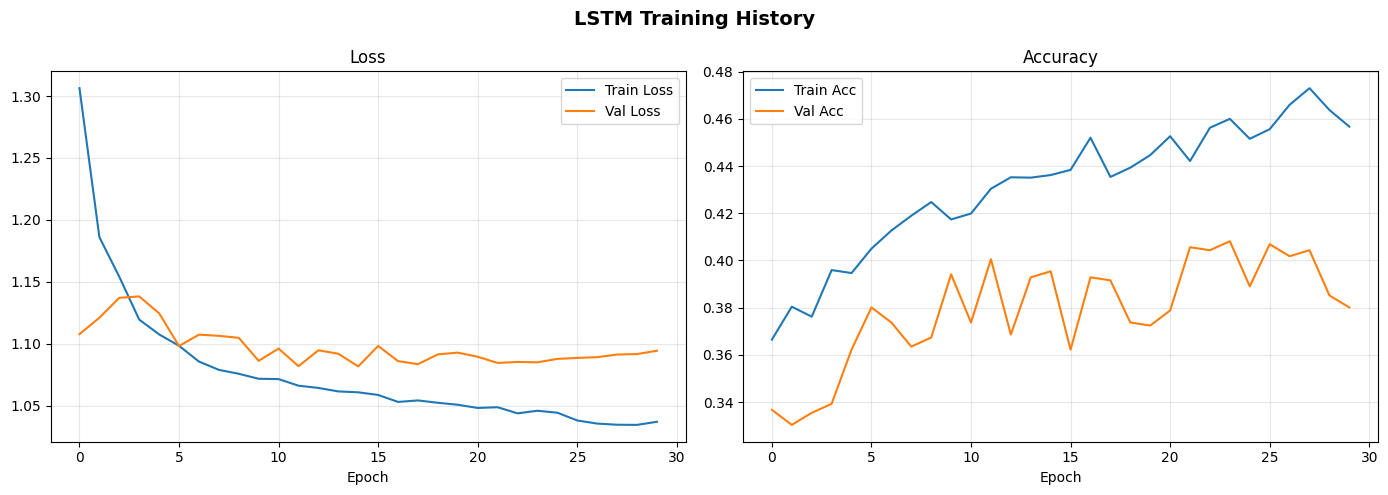

In [19]:
# ── Vẽ biểu đồ Loss/Accuracy ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Random Forest Regression**

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Làm phẳng dữ liệu sliding window từ 3D (samples, 16, 12) thành 2D (samples, 16*12)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 2. Huấn luyện Random Forest đơn giản (khống chế độ sâu để chống overfit)
clf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
clf.fit(X_train_flat, y_train)

# 3. Dự đoán và đánh giá
y_pred = clf.predict(X_test_flat)

print("=== KẾT QUẢ RANDOM FOREST ===")
print(classification_report(y_test, y_pred, target_names=['Giảm(0)', 'Đi ngang(1)', 'Tăng(2)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

=== KẾT QUẢ RANDOM FOREST ===
              precision    recall  f1-score   support

     Giảm(0)       0.33      0.47      0.39       150
 Đi ngang(1)       0.82      0.75      0.78       514
     Tăng(2)       0.31      0.26      0.28       121

    accuracy                           0.62       785
   macro avg       0.49      0.49      0.48       785
weighted avg       0.65      0.62      0.63       785

Confusion Matrix:
[[ 71  47  32]
 [ 93 385  36]
 [ 50  40  31]]


**SVM**

In [21]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Huấn luyện SVM phi tuyến tính với nhân RBF
clf_svm = SVC(C=1.0, kernel='rbf', class_weight='balanced', random_state=42)
clf_svm.fit(X_train_flat, y_train)

# Dự đoán
y_pred_svm = clf_svm.predict(X_test_flat)

print("=== KẾT QUẢ SVM (RBF KERNEL) ===")
print(classification_report(y_test, y_pred_svm, target_names=['Giảm(0)', 'Đi ngang(1)', 'Tăng(2)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

=== KẾT QUẢ SVM (RBF KERNEL) ===
              precision    recall  f1-score   support

     Giảm(0)       0.31      0.28      0.29       150
 Đi ngang(1)       0.85      0.61      0.71       514
     Tăng(2)       0.23      0.54      0.33       121

    accuracy                           0.54       785
   macro avg       0.46      0.48      0.44       785
weighted avg       0.65      0.54      0.57       785

Confusion Matrix:
[[ 42  29  79]
 [ 65 314 135]
 [ 29  27  65]]
